# Test out source code

In [5]:
using Pkg 
Pkg.activate("../.")
include("../src/model.jl")
include("../parameters/RA_short.jl")

  Activating project at `~/github/FisheriesInsuranceModel`


ComponentVector{Float64}(b0 = 1.0, g = 0.7710515858035663, m̄ = 0.4, m̲ = 1.0931471805599453, r0 = 0.15928442980271887, z = 0.75, b_target = 0.4, b_limit = 0.2, f_target = 0.38780092441132785, T = [0.975 0.5; 0.025 0.5], σ_R = 0.75, μZ = 0.0, μ_P = 9.315942614997402, μ_Ce = 0.0, s̄ = -2.0, k = 0.0, y0 = 0.01, cf = 1.0e-6, cv = 0.0, κ_bankrupt = 0.01, γ = 1.001)

## Set up random variables

In [6]:
X, Xmc = init_ranom_variables(p;Nquad = 3)

(ValueFunctionIterations.RandomVariableFunction(var"#Xf#10"{RandomVariable}(RandomVariable([0.0 0.0 … 0.0 0.0; 9.315942614997402 9.315942614997402 … 9.315942614997402 9.315942614997402; … ; -0.9185586535436918 -6.661338147750939e-16 … -6.661338147750939e-16 0.9185586535436918; 0.5 0.5 … 1.0 1.0], [0.12474542229323818, 0.2357022603955156, 0.12474542229323818, 0.11850815117857627, 0.2239171473757398, 0.11850815117857627, 0.0062372711146619145, 0.01178511301977579, 0.0062372711146619145]))), MCRandomVariable(3, 4, [-0.03206343995923034 -0.011716415117186749 0.012151838487562586; 9.28285865885945 9.335943516542098 9.247780706198652; … ; -0.08861182917270956 0.12724177222162328 0.1629266589121092; 0.5 0.975 1.0], [0.5, 0.475, 0.025000000000000022], var"#sampler#11"{ComponentVector{Float64, Vector{Float64}, Tuple{Axis{(b0 = 1, g = 2, m̄ = 3, m̲ = 4, r0 = 5, z = 6, b_target = 7, b_limit = 8, f_target = 9, T = ViewAxis(10:13, ShapedAxis((2, 2))), σ_R = 14, μZ = 15, μ_P = 16, μ_Ce = 17, s̄ = 18

## Check simulation

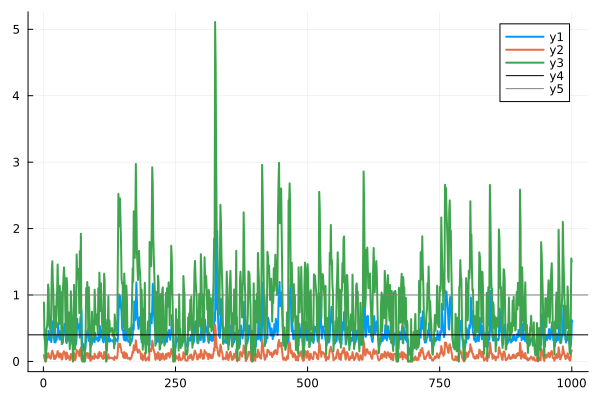

In [9]:
using Plots
X2, X2mc = init_ranom_variables(p;Nquad = 30)
states, m, f, h, y = simulate_trajectory(p,X2,1000)
Plots.plot(exp.(states[1,:]), width = 2)
Plots.plot!(h, width = 2)
Plots.plot!(y, width = 2)
Plots.hline!([p.b_target], color = "black")
Plots.hline!([y_target], color = "grey")

In [10]:
mean(y)

0.8627710591430222

## Check state grid

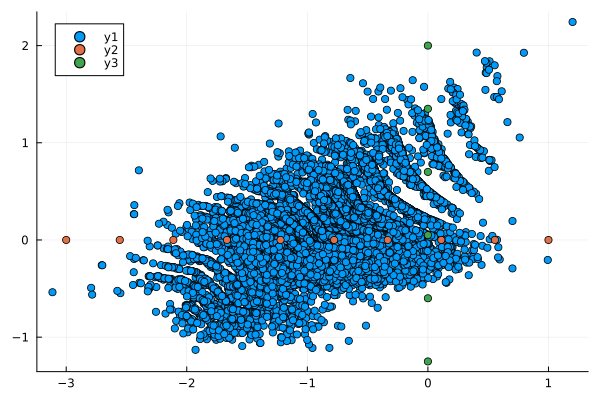

In [11]:
states, m, f, h, y = simulate_trajectory(p,X2,50000)
Plots.scatter(states[1,:], states[2,:])
bmax = 1.0; bmin = -3.0; Nb_grid = 10
b_grid = bmin:((bmax-bmin)/(Nb_grid-1)):bmax
Δbmax = 2; Δbmin = -1.25; NΔb_grid = 6
Δb_grid = Δbmin:((Δbmax-Δbmin)/(NΔb_grid-1)):Δbmax
Plots.scatter!(b_grid,[0.0])
Plots.scatter!(zeros(length(Δb_grid)),Δb_grid)

## Define remaining state grids

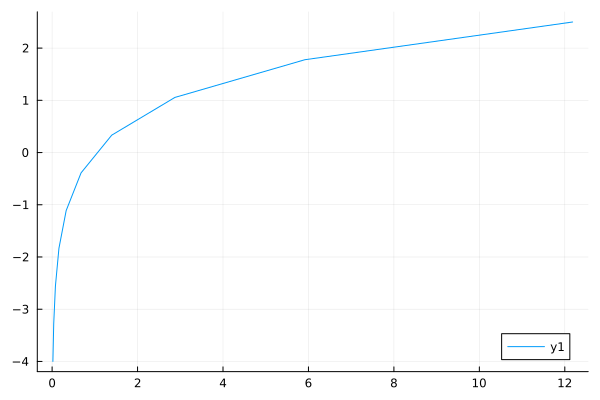

In [12]:
smax = 2.5; smin = -4.0; Ns_grid = 10
s_grid = smin:((smax-smin)/(Ns_grid-1)):smax
state_grid = [s_grid,b_grid,Δb_grid]
Plots.plot(exp.(s_grid),s_grid)

## Define aciton grid 

In [13]:
κmin = 0.01; κmax = 0.99; Nκ = 10
κ_grid = κmin:((κmax-κmin)/(Nκ-1)):κmax
ηmin = 0.0; ηmax=0.2; Nη = 6
η_grid = ηmin:((ηmax-ηmin)/(Nη-1)):ηmax
action_grid = [κ_grid,η_grid]
κ_grid

0.01:0.10888888888888888:0.99

# Define index and strike

# 

In [14]:
function strike(s,p)
    return 0.5*(p.b_target +p.b_limit) 
end

function index(s,X)
    return exp(s[1])+X[1]
end 

index (generic function with 1 method)

In [15]:
0.5*(p.b_target +p.b_limit) 

0.30000000000000004

## Set up model 

In [16]:
δ = 0.95
prob, El = init(action_grid,state_grid,δ,p,X,index,strike)
estimate_time(prob)

The wieght in the random variable do not add to one, there might be an issue with your integration method.

("Estimate (sec)" => 29.2, "One call" => 8.66389274597168e-6, "Number of computations" => 561744, "actions" => "varaible", "states" => 1216, "random variable samples" => 9, "Estimated iterations" => 60, "Number of threads" => 10)

In [17]:
solve!(prob,maxiter = 20)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:25


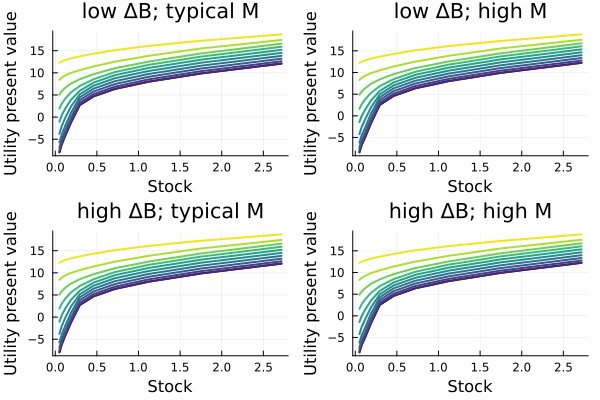

In [18]:
include("../src/plotting.jl")
plot_value_function(prob)

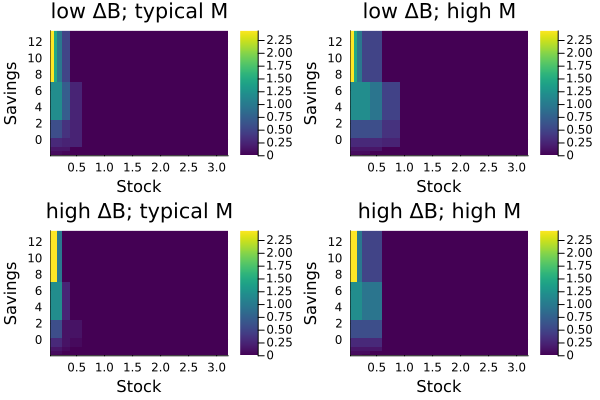

In [19]:
plot_premiums(prob)

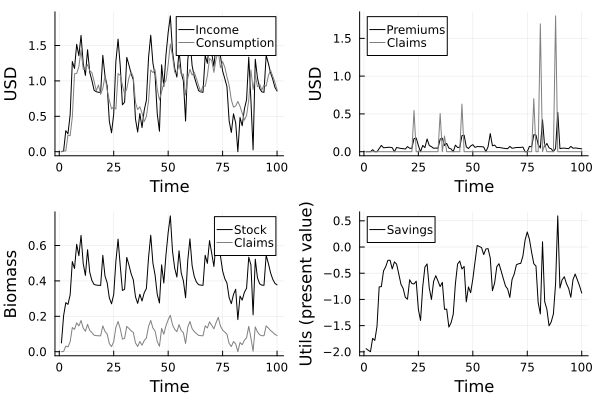

In [52]:
include("../src/plotting.jl")
plot_simulation(prob,El,100;with_policy = false)